# XGBoost超参数优化：XGBRegressor  最优超参数确定（调参）
## 超参数调优方法：网格搜索，随机搜索，贝叶斯优化等算法
### 2025.02.13 
## 2025.2.21 不同优化的预测效果对比
## 2025.4.19 优化输出图片质量和尺寸
### sunyu 

XGBRegressor 调整如下参数：
框架参数 XGBRegressor #1: learning_rate
        XGBRegressor #2: n_estimators
        XGBRegressor #3: max_depth
        XGBRegressor #4: subsample
        XGBRegressor #5: alpha
树参数
        XGBRegressor #6: max_depth
        XGBRegressor #7: max_features
        XGBRegressor #8: min_samples_split 
        XGBRegressor #9: min_samples_leaf
        XGBRegressor #10: max_leaf_nodes
        XGBRegressor #11: verbose                            
The type of output to be printed when the model fits. The different values can be:                            
0: no output generated (defaul )
1: output generated for trees in certain inter  ls
>1: output generated for ant XGBRessorate

# API  Default parameters
class sklearn.ensemble.XGBRegressor(
max_depth=3, learning_rate=0.1, n_estimators=100, verbosity=1, silent=None, objective='reg:squarederror', booster='gbtree', n_jobs=1, nthread=None, gamma=0, min_child_weight=1, max_delta_step=0, subsample=1, colsample_bytree=1, colsample_bylevel=1, colsample_bynode=1, reg_alpha=0, reg_lambda=1, scale_pos_weight=1, base_score=0.5, random_state=0, seed=None, missing=None, importance_type='gain')

In [1]:
#导入库
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from lightgbm.sklearn import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor  #GBDT
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor  #XGBoosting

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Skopt functions   
from skopt import BayesSearchCV
#from skopt.callbacks import DeadlineStopper, DeltaYStopper
#from skopt.space import Real, Categorical, Integer
#No module named 'skopt':  pip install scikit-optimize

from hyperopt import fmin, tpe, hp, anneal, Trials

import seaborn as sns
import matplotlib.pyplot as plt

import math
from scipy.stats import randint
import timeit
import os
import psutil
import missingno as msno

In [2]:
import sklearn
print(sklearn.__version__)

1.5.1


## Hyperopt是一个用于复杂空间下的函数最小化的Python库。它具有强大的灵活性，能处理非常复杂的参数空间。与Skopt不同，Hyperopt使用的是序列模型和贝叶斯优化，并且提供了TPE（树形结构的程序代理）算法来指导搜索。

In [3]:
# 读取CSV文件
test_results_all = pd.read_csv('test_predictions_gs20250223OK.csv',header=0)  #,encoding='gbk'

In [4]:
test_results_all

,Actual,Predicted_gs,Predicted_rs,Predicted_tpe,Predicted_as
0,22.00,37.617638,34.305280,26.340706,29.709335
1,23.87,27.540834,26.308346,28.961687,29.110640
2,29.31,32.213440,34.871525,31.109740,32.326214
3,29.58,34.929250,33.034610,31.892290,32.980640
4,30.20,35.151400,34.186780,29.699684,28.859530
5,31.40,41.270626,36.068490,32.732395,33.848377
6,32.00,40.107750,38.040640,34.178890,36.263570
7,39.38,30.520302,32.492502,37.472546,35.315819
8,40.20,37.314323,36.071888,37.600372,35.795906
9,41.51,44.406742,47.739704,43.963490,46.675860


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


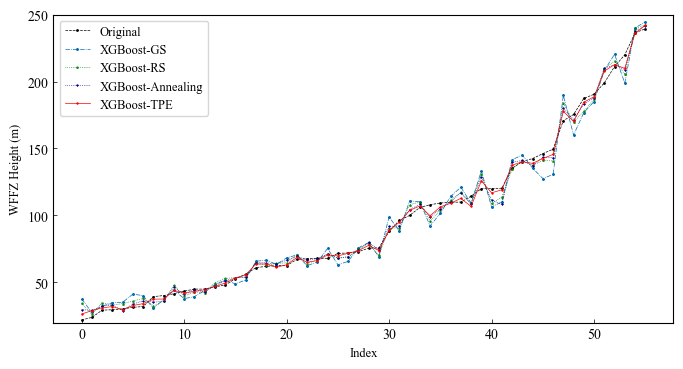

In [5]:
from matplotlib.pyplot import MultipleLocator
#fig, ax = plt.subplots(1, 1, figsize=(8, 4))  # 3行1列的子图   #plt.figure(figsize=(18/2.54, 5/2.54),dpi=400)
plt.figure(figsize=(8, 4))
plt.rcParams["font.family"] = "Times New Roman"

# 网格优化'-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
x_ax = range(len(test_results_all))
plt.plot(test_results_all.index,test_results_all['Actual'], label='Original', color='black',linestyle='--', linewidth=0.5,  marker='o',markersize=1)#
plt.plot(test_results_all.index,test_results_all['Predicted_gs'], label='XGBoost-GS', color='#006BB2', linestyle='-.',linewidth=0.5, marker='D', markersize=1) ##B22400
plt.plot(test_results_all.index,test_results_all['Predicted_rs'], label='XGBoost-RS', color='green', linestyle=':',linewidth=0.5, marker='^', markersize=1)
plt.plot(test_results_all.index,test_results_all['Predicted_as'], label='XGBoost-Annealing', color='darkblue', linestyle='dotted',linewidth=0.5,marker='*',  markersize=1)
plt.plot(test_results_all.index,test_results_all['Predicted_tpe'], label='XGBoost-TPE', color='red', linewidth=0.5,marker='+',  markersize=1) #linestyle='dotted',
# 设置标题和标签
plt.xlabel('Index', fontsize=9) #, weight='bold'
plt.ylabel('WFFZ Height (m)', fontsize=9) #, weight='bold'
plt.legend(fontsize=9,loc='best') #'upper left'
y_major_locator=MultipleLocator(50)
plt.ylim(20,250)
plt.tick_params(axis='both', which='both', direction='in', length=3, width=0.5)
plt.grid(False) #, which='both', linestyle='--', linewidth=0.5
#plt.rcParams['ytick.right'] = plt.rcParams['ytick.labelright'] = False
#plt.rcParams['ytick.left'] = plt.rcParams['ytick.labelleft'] = True

# 保存为适合出版的图片格式
plt.savefig('XGBoost_regression_WFFZ0419.tiff',bbox_inches='tight', dpi=300)
plt.savefig('XGBoost_regression_WFFZ0419.pdf',bbox_inches='tight', dpi=300)
plt.savefig('XGBoost_regression_WFFZ0419.eps',bbox_inches='tight', dpi=300)
plt.show()

In [6]:
# 读取CSV文件
test_results_MSE_CT = pd.read_csv('prediction_MSE_CT.csv',header=0)  #,encoding='gbk'

In [7]:
test_results_MSE_CT

,HPO,MSE,CT
0,GS,897.621,142.096
1,RS,791.574,0.802
2,TPE,717.363,4.189
3,Annealing,734.125,3.475


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


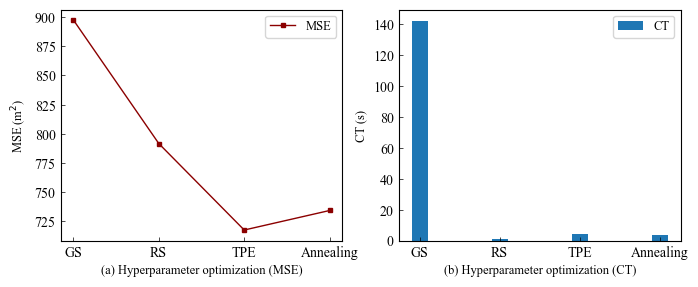

In [8]:
from matplotlib.pyplot import MultipleLocator
fig, ax = plt.subplots(1, 2, figsize=(8, 3))  # 3行1列的子图   #plt.figure(figsize=(18/2.54, 5/2.54),dpi=400)
#plt.figure(figsize=(5, 3))
plt.rcParams["font.family"] = "Times New Roman"
# 网格优化'-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
#x_ax = range(len(test_results_all))
ax[0].plot(['GS','RS','TPE','Annealing'],test_results_MSE_CT['MSE'], label='MSE', color='darkred',linestyle='-', linewidth=1,  marker='s',markersize=3)#
#test_results_MSE_CT.index
# 设置标题和标签
ax[0].set_xlabel('(a) Hyperparameter optimization (MSE)', fontsize=9) #, weight='bold'
ax[0].set_ylabel(r'MSE (m$^2$)', fontsize=9) #, weight='bold'
ax[0].legend(['MSE'],fontsize=9,loc='best') #'upper left'
ax[0].tick_params(axis='both', which='both', direction='in', length=3, width=0.5)#bottom=False, left=False
ax[0].yaxis.tick_left()

ax[1].bar(['GS','RS','TPE','Annealing'],test_results_MSE_CT['CT'], label='CT', color='tab:blue', width=0.2) #linestyle='-.',linewidth=0.5), marker='D', markersize=1) ##B22400
ax[1].set_xlabel('(b) Hyperparameter optimization (CT)', fontsize=9) #, weight='bold'  tick_label=test_results_MSE_CT['HPO'],
ax[1].set_ylabel('CT (s)', fontsize=9) #, weight='bold'
ax[1].legend(['CT'],fontsize=9,loc='best') #'upper left'
ax[1].tick_params(axis='both', which='both', direction='in', length=3, width=0.5) #'both'
ax[1].yaxis.tick_left()
#plt.plot(test_results_all.index,test_results_all['Predicted_rs'], label='XGBoost-RS', color='green', linestyle=':',linewidth=0.5)#, marker='^', markersize=1)
#plt.plot(test_results_all.index,test_results_all['Predicted_as'], label='XGBoost-Annealing', color='darkblue', linestyle='dotted',linewidth=0.5)#,marker='*',  markersize=1)
#plt.plot(test_results_all.index,test_results_all['Predicted_tpe'], label='XGBoost-TPE', color='red', linewidth=0.5)#,marker='+',  markersize=1) #linestyle='dotted',
#y_major_locator=MultipleLocator(50)
#plt.ylim(20,250)
#plt.tick_params(axis='both', which='both', direction='in', length=4, width=1.5)
plt.grid(False) #, which='both', linestyle='--', linewidth=0.5
# 保存为适合出版的图片格式
plt.savefig('XGBoost_regression_MSE_CT0419.tiff',  bbox_inches='tight', dpi=300)
plt.savefig('XGBoost_regression_MSE_CT0419.pdf',  bbox_inches='tight', dpi=300)
plt.savefig('XGBoost_regression_MSE_CT0419.eps',  bbox_inches='tight', dpi=300)
plt.show()

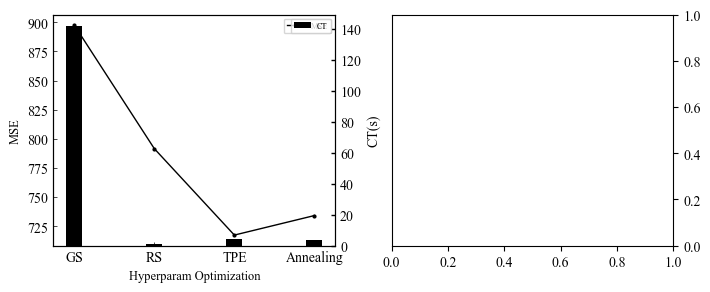

In [39]:
from matplotlib.pyplot import MultipleLocator
fig, ax = plt.subplots(1, 2, figsize=(8, 3))  # 3行1列的子图   #plt.figure(figsize=(18/2.54, 5/2.54),dpi=400)
#plt.figure(figsize=(5, 3))
plt.rcParams["font.family"] = "Times New Roman"
# 网格优化'-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
x_ax = range(len(test_results_all))
ax[0].plot(['GS','RS','TPE','Annealing'],test_results_MSE_CT['MSE'], label='MSE', color='black',linestyle='-', linewidth=1,  marker='o',markersize=2)#
#test_results_MSE_CT.index
# 设置标题和标签
ax[0].set_xlabel('Hyperparam Optimization', fontsize=9) #, weight='bold'
ax[0].set_ylabel('MSE', fontsize=9) #, weight='bold'
ax[0].legend(fontsize=6,loc='best') #'upper left'
ax[0].tick_params(axis='both', which='both', direction='in', length=3, width=0.5,bottom=True, left=True,right=False)
ax[0].legend(['MSE'],fontsize=6,loc='best')

ax2=ax[0].twinx()
ax2.set_xlabel('Hyperparam Optimization', fontsize=9)
ax2.set_ylabel('CT(s)')
ax2.bar(['GS','RS','TPE','Annealing'],test_results_MSE_CT['CT'], label='CT', color='black', width=0.2)
ax2.legend(['CT'],fontsize=6,loc='best')
ax2.tick_params(axis='y', which='both', direction='in', length=3, width=1)
plt.grid(False) #, which='both', linestyle='--', linewidth=0.5
# 保存为适合出版的图片格式
#plt.savefig('XGBoost_regression_MSE_CT.png', dpi=400)
plt.show()

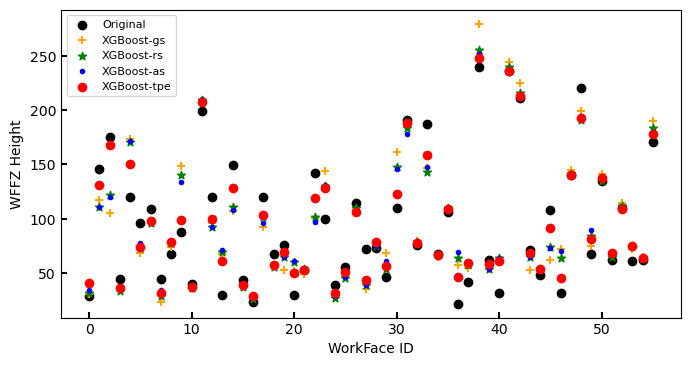

In [25]:
# 4. 创建一个图形窗口，包含多个子图
#fig, ax = plt.subplots(1, 1, figsize=(8, 4))  # 3行1列的子图   #plt.figure(figsize=(18/2.54, 5/2.54),dpi=400)
rc.params['']
plt.figure(figsize=(8, 4))
# 网格优化
x_ax = range(len(test_data))
plt.scatter(test_results_all.index,test_results_all['Actual'], label='Original', color='black',   marker='o')#linewidth=1,marker='o',
plt.scatter(test_results_all.index,test_results_all['Predicted_gs'], label='XGBoost-gs', color='orange',  marker='+') # linestyle='-.',linewidth=1,
plt.scatter(test_results_all.index,test_results_all['Predicted_rs'], label='XGBoost-rs', color='green',   marker='*') #linestyle='--',linewidth=1,
plt.scatter(test_results_all.index,test_results_all['Predicted_as'], label='XGBoost-as', color='blue',   marker='.') #linestyle='-',linewidth=1,
plt.scatter(test_results_all.index,test_results_all['Predicted_tpe'], label='XGBoost-tpe', color='red',   marker='o') #linewidth=1,
# 设置标题和标签
plt.xlabel('WorkFace ID', fontsize=10) #, weight='bold'
plt.ylabel('WFFZ Height', fontsize=10) #, weight='bold'
plt.legend(fontsize=8,loc='upper left')
plt.tick_params(axis='both', which='both', direction='in', length=4, width=1.5)
plt.grid(False) #, which='both', linestyle='--', linewidth=0.5
# 保存为适合出版的图片格式
#plt.savefig('XGBoost_regression_WFFZ0220.png', dpi=400)
plt.show()